In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("hypothetical_health_data.csv")

# Preview the data
print(df.head())


,age,gender,smoking,alcohol_use,family_history,physical_activity,cholesterol_level,blood_pressure,diabetes,diet_quality,obesity,has_heart_disease,has_cancer
0,63,Female,0,0,0,Low,167,127,0,Average,0,0,0
1,76,Male,1,1,0,Low,233,176,0,Average,0,0,0
2,53,Female,0,0,0,Low,184,110,0,Average,0,0,0
3,39,Male,0,1,0,Medium,263,154,0,Average,0,0,0
4,67,Male,1,0,1,Medium,295,110,0,Good,0,0,0


In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                1000 non-null   int64 
 1   gender             1000 non-null   object
 2   smoking            1000 non-null   int64 
 3   alcohol_use        1000 non-null   int64 
 4   family_history     1000 non-null   int64 
 5   physical_activity  1000 non-null   object
 6   cholesterol_level  1000 non-null   int64 
 7   blood_pressure     1000 non-null   int64 
 8   diabetes           1000 non-null   int64 
 9   diet_quality       1000 non-null   object
 10  obesity            1000 non-null   int64 
 11  has_heart_disease  1000 non-null   int64 
 12  has_cancer         1000 non-null   int64 
dtypes: int64(10), object(3)
memory usage: 101.7+ KB


,0
age,0
gender,0
smoking,0
alcohol_use,0
family_history,0
physical_activity,0
cholesterol_level,0
blood_pressure,0
diabetes,0
diet_quality,0


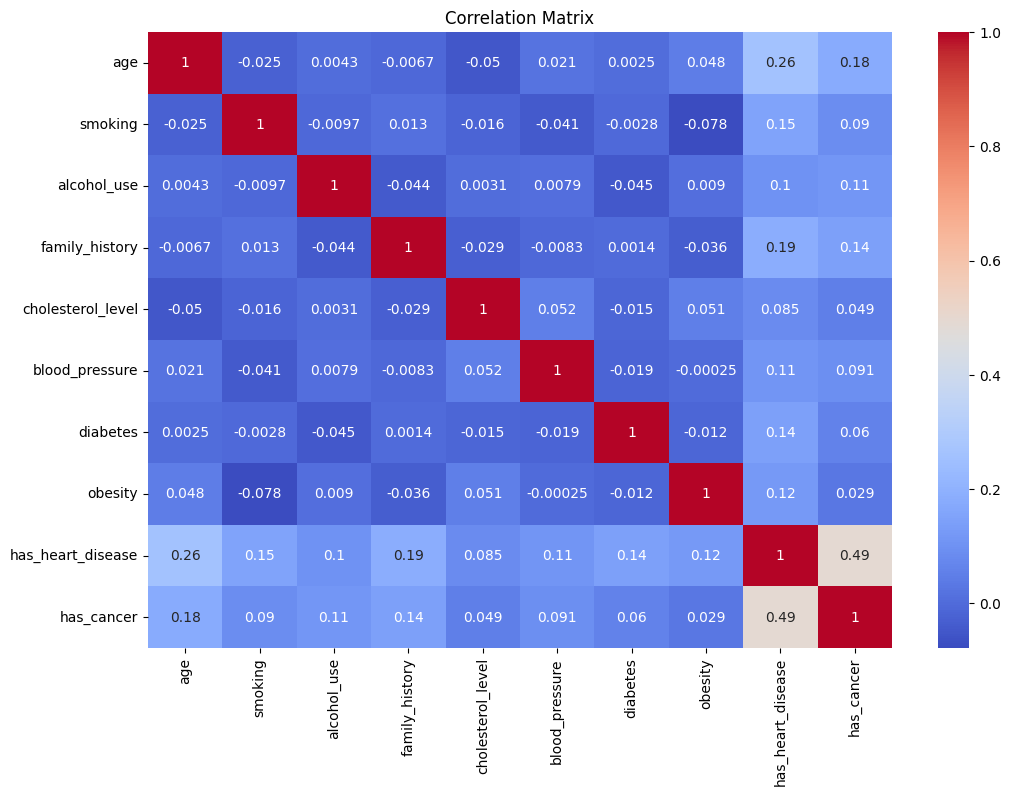

In [ ]:
# Step 3: Explore and visualize data
import matplotlib.pyplot as plt
import seaborn as sns

print(df.info())
print(df.describe())
print(df.isnull().sum())

# Visualization examples
sns.countplot(x='has_heart_disease', hue='gender', data=df)
plt.title("Heart Disease by Gender")
plt.show()

sns.countplot(x='physical_activity', hue='has_cancer', data=df)
plt.title("Cancer by Physical Activity")
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()






In [ ]:
# Step 4: Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode categorical columns
df['gender'] = LabelEncoder().fit_transform(df['gender'])
df['physical_activity'] = LabelEncoder().fit_transform(df['physical_activity'])
df['diet_quality'] = LabelEncoder().fit_transform(df['diet_quality'])

# Preprocessing function
def preprocess_and_split(target_column):
    X = df.drop(['has_heart_disease', 'has_cancer'], axis=1)
    y = df[target_column]
    X_scaled = StandardScaler().fit_transform(X)
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_hd, X_test_hd, y_train_hd, y_test_hd = preprocess_and_split('has_heart_disease')
X_train_ca, X_test_ca, y_train_ca, y_test_ca = preprocess_and_split('has_cancer')


Accuracy: 0.955
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       187
           1       1.00      0.31      0.47        13

    accuracy                           0.95       200
   macro avg       0.98      0.65      0.72       200
weighted avg       0.96      0.95      0.94       200



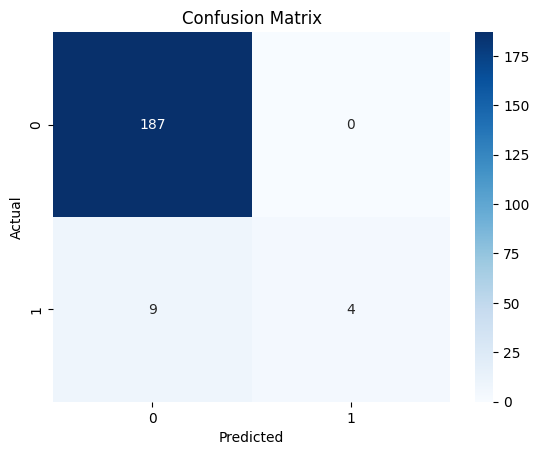

In [ ]:
# Step 5: Train classification model for heart disease
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model_hd = RandomForestClassifier(random_state=42)
model_hd.fit(X_train_hd, y_train_hd)
y_pred_hd = model_hd.predict(X_test_hd)

print("Heart Disease Classification Report:")
print(classification_report(y_test_hd, y_pred_hd))
print("Accuracy:", accuracy_score(y_test_hd, y_pred_hd))

sns.heatmap(confusion_matrix(y_test_hd, y_pred_hd), annot=True, fmt='d', cmap='Blues')
plt.title("Heart Disease Confusion Matrix")
plt.show()


In [ ]:
# Step 6: Train classification model for cancer
model_ca = RandomForestClassifier(random_state=42)
model_ca.fit(X_train_ca, y_train_ca)
y_pred_ca = model_ca.predict(X_test_ca)

print("Cancer Classification Report:")
print(classification_report(y_test_ca, y_pred_ca))
print("Accuracy:", accuracy_score(y_test_ca, y_pred_ca))

sns.heatmap(confusion_matrix(y_test_ca, y_pred_ca), annot=True, fmt='d', cmap='Oranges')
plt.title("Cancer Confusion Matrix")
plt.show()


Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Improved Accuracy: 0.955


In [ ]:
# Step 7: Improve accuracy using hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid_hd = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_hd.fit(X_train_hd, y_train_hd)

print("Best Parameters for Heart Disease:", grid_hd.best_params_)

best_model_hd = grid_hd.best_estimator_
y_best_pred_hd = best_model_hd.predict(X_test_hd)
print("Improved Accuracy:", accuracy_score(y_test_hd, y_best_pred_hd))


In [ ]:
# See first 10 predictions for heart disease
print("Heart Disease Predictions:", y_pred_hd[:10])

# See first 10 predictions for cancer
print("Cancer Predictions:", y_pred_ca[:10])


In [ ]:
# Show predictions alongside original data
heart_results = pd.DataFrame({
    "Actual": y_test_hd[:10].values,
    "Predicted": y_pred_hd[:10]
})
print("Heart Disease Results (0=No, 1=Yes):")
print(heart_results)

cancer_results = pd.DataFrame({
    "Actual": y_test_ca[:10].values,
    "Predicted": y_pred_ca[:10]
})
print("Cancer Results (0=No, 1=Yes):")
print(cancer_results)
